<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Lab: Exploratory Data Analysis**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis or EDA. 


## Objectives


In this lab, you will perform the following:


- Examine the structure of a dataset.

- Handle missing values effectively.

- Conduct summary statistics on key columns.

- Analyze employment status, job satisfaction, programming language usage, and trends in remote work.


## Hands on Lab


#### Step 1: Install and Import Libraries


Install the necessary libraries for data manipulation and visualization.


In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Step 2: Load and Preview the Dataset
Load the dataset from the provided URL. Use df.head() to display the first few rows to get an overview of the structure.


In [ ]:
# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Set pandas option to display all columns
pd.set_option('display.max_columns', None)

# Display the first few rows of the dataset
df.head()

#### Step 3: Handling Missing Data


Identify and manage missing values in critical columns such as `Employment`, `JobSat`, and `RemoteWork`. Implement a strategy to fill or drop these values, depending on the significance of the missing data.


In [ ]:
# Step 3: Handling Missing Data

critical_cat_cols = ["Employment", "JobSat", "RemoteWork"]
for col in critical_cat_cols:
    if col in df.columns:
        df[col] = df[col].astype("string")
        df[col] = df[col].fillna("Unknown").str.strip()

# If JobSatPoints_1 exists (numeric satisfaction), handle missing values for analysis
if "JobSatPoints_1" in df.columns:
    df["JobSatPoints_1"] = pd.to_numeric(df["JobSatPoints_1"], errors="coerce")
    df["JobSatPoints_1"] = df["JobSatPoints_1"].fillna(df["JobSatPoints_1"].median())

# Quick check
missing_after = df[critical_cat_cols].isna().sum() if all(c in df.columns for c in critical_cat_cols) else df.isna().sum()
print("Missing values after handling (key columns):")
display(missing_after)

#### Step 4: Analysis of Experience and Job Satisfaction


Analyze the relationship between years of professional coding experience (`YearsCodePro`) and job satisfaction (`JobSat`). Summarize `YearsCodePro` and calculate median satisfaction scores based on experience ranges.

- Create experience ranges for `YearsCodePro` (e.g., `0-5`, `5-10`, `10-20`, `>20` years).

- Calculate the median `JobSat` for each range.

- Visualize the relationship using a bar plot or similar visualization.


In [ ]:
# Convert YearsCodePro to numeric values

years = df["YearsCodePro"].astype("string").str.strip()

years = years.replace({
    "Less than 1 year": "0",
    "More than 50 years": "51"
})

df["YearsCodePro_num"] = pd.to_numeric(years, errors="coerce")

# Define bins
bins = [-1, 5, 10, 20, 100]
labels = ["0-5", "5-10", "10-20", ">20"]

# Create new column
df["ExperienceRange"] = pd.cut(df["YearsCodePro_num"], bins=bins, labels=labels)

df[["YearsCodePro", "YearsCodePro_num", "ExperienceRange"]].head(10)

In [ ]:
# Choose satisfaction measure:
# Prefer numeric JobSatPoints_1 if present, otherwise map JobSat categories to an ordinal scale.
if "JobSatPoints_1" in df.columns:
    sat_col = "JobSatPoints_1"
else:
    sat_col = "JobSat"
    # Simple ordinal mapping (only used if numeric satisfaction column isn't available)
    job_sat_map = {
        "Very satisfied": 5,
        "Satisfied": 4,
        "Neither satisfied nor dissatisfied": 3,
        "Slightly dissatisfied": 2,
        "Very dissatisfied": 1,
        "Unknown": None
    }
    df["JobSat_ordinal"] = df["JobSat"].map(job_sat_map)
    sat_col = "JobSat_ordinal"

In [ ]:
# Create experience bins
bins = [-0.1, 5, 10, 20, 1000]
labels = ["0-5", "5-10", "10-20", ">20"]
df["ExperienceRange"] = pd.cut(df["YearsCodePro_num"], bins=bins, labels=labels)

In [ ]:
# Median satisfaction by experience range
med_by_range = (
    df.groupby("ExperienceRange", dropna=False)[sat_col]
      .median()
      .reindex(labels)
)

print("Median satisfaction by experience range:")
display(med_by_range)

In [ ]:
# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=med_by_range.index.astype(str), y=med_by_range.values)
plt.title("Median Job Satisfaction by Years of Professional Coding Experience")
plt.xlabel("YearsCodePro Range")
plt.ylabel(f"Median Satisfaction ({sat_col})")
plt.tight_layout()
plt.show()

#### Step 5: Visualize Job Satisfaction


Use a count plot to show the distribution of `JobSat` values. This provides insights into the overall satisfaction levels of respondents.


In [ ]:
# Step 5: Visualize Job Satisfaction (count plot)

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="JobSat", order=df["JobSat"].value_counts().index)
plt.title("Distribution of Job Satisfaction (JobSat)")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

#### Step 6: Analyzing Remote Work Preferences by Job Role


Analyze trends in remote work based on job roles. Use the `RemoteWork` and `Employment` columns to explore preferences and examine if specific job roles prefer remote work more than others.

- Use a count plot to show remote work distribution.

- Cross-tabulate remote work preferences by employment type (e.g., full-time, part-time) and job roles.


In [ ]:
# 6.1 Count plot for RemoteWork
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="RemoteWork", order=df["RemoteWork"].value_counts().index)
plt.title("Remote Work Preference Distribution")
plt.xlabel("RemoteWork")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

#### Step 7: Analyzing Programming Language Trends by Region


Analyze the popularity of programming languages by region. Use the `LanguageHaveWorkedWith` column to investigate which languages are most used in different regions.

- Filter data by country or region.

- Visualize the top programming languages by region with a bar plot or heatmap.


LanguageHaveWorkedWith,Bash/Shell (all shells),C,C#,C++,HTML/CSS,Java,JavaScript,PHP,PowerShell,Python,SQL,TypeScript
Country,,,,,,,,,,,,
France,858,594,410,567,1114,706,1281,520,277,1186,1069,861
Germany,1970,1147,1185,1315,2514,1818,2732,913,738,2640,2297,1868
India,759,1084,645,1127,2322,1549,2730,722,353,2128,1986,1405
Ukraine,579,256,612,430,1198,664,1532,396,203,961,1215,980
United Kingdom of Great Britain and Northern Ireland,1231,563,1089,651,1707,701,2011,494,576,1634,1663,1190
United States of America,4776,2225,3112,2607,5754,2949,6849,1343,1865,6238,5766,4173


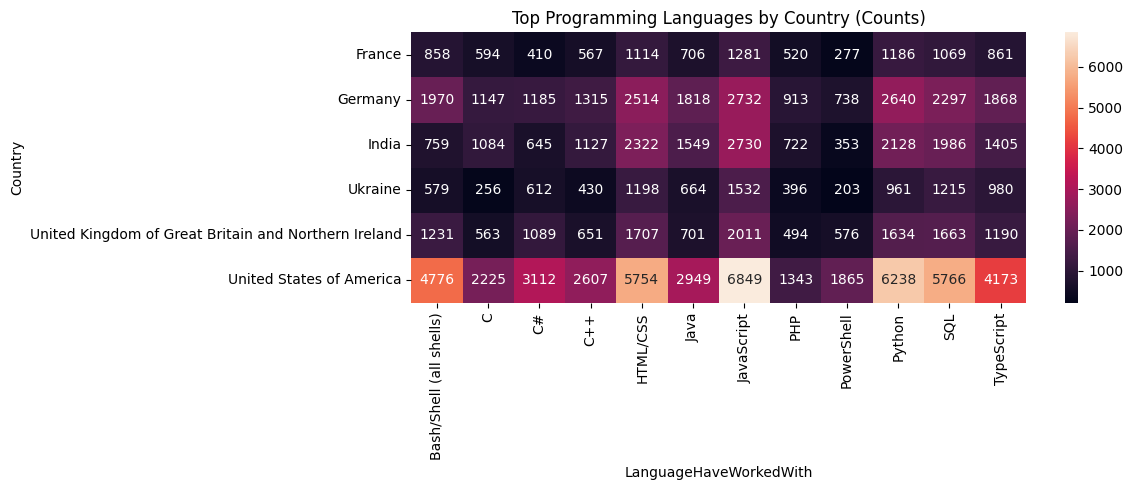

In [23]:
# Step 7: Programming Language Trends by Region

if "LanguageHaveWorkedWith" not in df.columns or "Country" not in df.columns:
    raise KeyError("Required columns not found: Country and/or LanguageHaveWorkedWith")

lang_df = df[["Country", "LanguageHaveWorkedWith"]].dropna().copy()
lang_df["Country"] = lang_df["Country"].astype("string").str.strip()
lang_df["LanguageHaveWorkedWith"] = lang_df["LanguageHaveWorkedWith"].astype("string")

# Split multiple languages into rows
lang_df = lang_df.assign(LanguageHaveWorkedWith=lang_df["LanguageHaveWorkedWith"].str.split(";")).explode("LanguageHaveWorkedWith")
lang_df["LanguageHaveWorkedWith"] = lang_df["LanguageHaveWorkedWith"].str.strip()

# Select top countries by respondent count
top_countries = df["Country"].value_counts().head(6).index
lang_df = lang_df[lang_df["Country"].isin(top_countries)]

# Select top languages overall within these countries
top_langs = lang_df["LanguageHaveWorkedWith"].value_counts().head(12).index
lang_df = lang_df[lang_df["LanguageHaveWorkedWith"].isin(top_langs)]

pivot = pd.pivot_table(
    lang_df,
    index="Country",
    columns="LanguageHaveWorkedWith",
    values="LanguageHaveWorkedWith",
    aggfunc="count",
    fill_value=0
)

display(pivot)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt="d")
plt.title("Top Programming Languages by Country (Counts)")
plt.xlabel("LanguageHaveWorkedWith")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

#### Step 8: Correlation Between Experience and Satisfaction


Examine how years of experience (`YearsCodePro`) correlate with job satisfaction (`JobSatPoints_1`). Use a scatter plot to visualize this relationship.


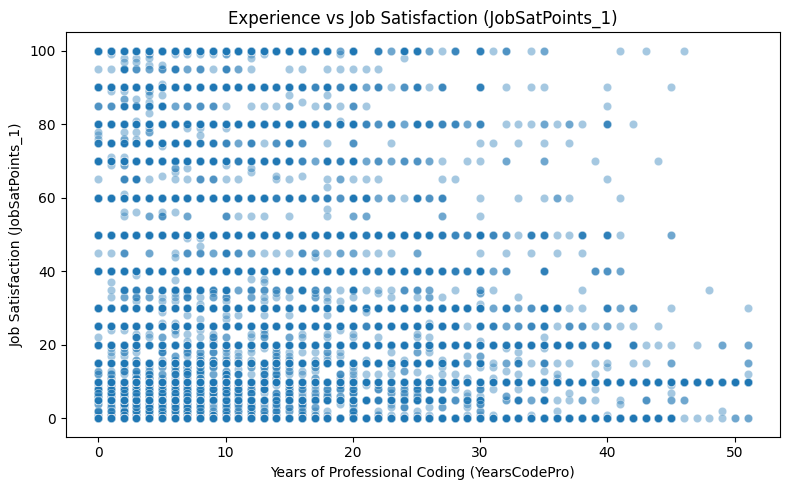

Correlation (YearsCodePro_num vs JobSatPoints_1): -0.017


In [22]:
# Step 8: Correlation Between Experience and Satisfaction

if "YearsCodePro_num" not in df.columns:
    # Create numeric version if not already created
    y = df["YearsCodePro"].astype("string").str.strip()
    y = y.replace({"Less than 1 year": "0", "More than 50 years": "51"})
    df["YearsCodePro_num"] = pd.to_numeric(y, errors="coerce")

if "JobSatPoints_1" not in df.columns:
    raise KeyError("JobSatPoints_1 not found. This step expects a numeric satisfaction column.")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="YearsCodePro_num", y="JobSatPoints_1", alpha=0.4)
plt.title("Experience vs Job Satisfaction (JobSatPoints_1)")
plt.xlabel("Years of Professional Coding (YearsCodePro)")
plt.ylabel("Job Satisfaction (JobSatPoints_1)")
plt.tight_layout()
plt.show()

# Optional: correlation value
corr = df[["YearsCodePro_num", "JobSatPoints_1"]].corr().iloc[0, 1]
print("Correlation (YearsCodePro_num vs JobSatPoints_1):", round(corr, 3))

#### Step 9: Educational Background and Employment Type


Explore how educational background (`EdLevel`) relates to employment type (`Employment`). Use cross-tabulation and visualizations to understand if higher education correlates with specific employment types.


In [ ]:
# Step 9: Educational Background and Employment Type

if "EdLevel" not in df.columns or "Employment" not in df.columns:
    raise KeyError("Required columns not found: EdLevel and/or Employment")

edu_emp = pd.crosstab(df["EdLevel"], df["Employment"], normalize="index")
print("Employment distribution within each education level (row-normalized):")
display(edu_emp)

plt.figure(figsize=(12, 6))
sns.heatmap(edu_emp, annot=True, fmt=".2f")
plt.title("Employment Type by Education Level (Proportions)")
plt.xlabel("Employment")
plt.ylabel("EdLevel")
plt.tight_layout()
plt.show()

#### Step 10: Save the Cleaned and Analyzed Dataset


After your analysis, save the modified dataset for further use or sharing.


In [ ]:
# Step 10: Save the Cleaned and Analyzed Dataset

output_file = "survey_data_cleaned_eda.csv"
df.to_csv(output_file, index=False)

print("Saved cleaned dataset to:", output_file)
print("Final shape:", df.shape)

<h2>Summary</h2>


In this revised lab, you:

- Loaded and explored the structure of the dataset.

- Handled missing data effectively.

- Analyzed key variables, including working hours, job satisfaction, and remote work trends.

- Investigated programming language usage by region and examined the relationship between experience and satisfaction.

- Used cross-tabulation to understand educational background and employment type.


Copyright © IBM Corporation. All rights reserved.
